In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, accuracy_score)
from xgboost import XGBClassifier

print("✅ Bibliothèques chargées avec succès !")

✅ Bibliothèques chargées avec succès !


In [3]:
# Charger directement les données RFM depuis Notebook 01
rfm = pd.read_csv(r'E:\projet stage PFE\PFE-Marjane-Optimization\rfm_export.csv')

print(f"✅ Données RFM chargées depuis Notebook 01")
print(f"📊 Shape    : {rfm.shape}")
print(f"🧍 Clients  : {rfm.shape[0]}")
print(f"📋 Colonnes : {list(rfm.columns)}")
print(f"\n{rfm.describe().round(2)}")

✅ Données RFM chargées depuis Notebook 01
📊 Shape    : (5860, 10)
🧍 Clients  : 5860
📋 Colonnes : ['Recency', 'Frequency', 'Monetary', 'City', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score', 'Cluster', 'Segment_Name']

       Recency  Frequency   Monetary  R_Score  F_Score  M_Score  RFM_Score  \
count  5860.00    5860.00    5860.00  5860.00  5860.00  5860.00    5860.00   
mean    200.98       6.22    2956.47     2.49     2.50     2.50     276.66   
std     207.49      12.86   14352.38     1.12     1.12     1.12     106.56   
min       1.00       1.00       2.90     1.00     1.00     1.00     111.00   
25%      26.00       1.00     344.49     1.00     1.75     1.75     144.00   
50%     101.00       3.00     883.60     2.00     2.50     2.50     244.00   
75%     376.00       7.00    2284.65     3.00     3.25     3.25     344.00   
max     734.00     391.00  597336.11     4.00     4.00     4.00     444.00   

       Cluster  
count  5860.00  
mean      1.31  
std       0.95  
min       0.0

  Clients actifs  (0) :  3453 (58.9%)
  Clients churnés (1) :  2407 (41.1%)
  Total           :  5860


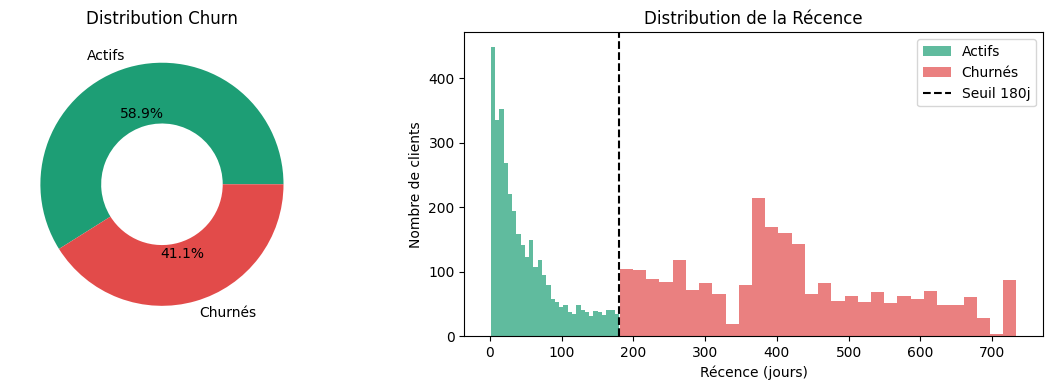

In [6]:
SEUIL_CHURN = 180

rfm['Churn'] = (rfm['Recency'] > SEUIL_CHURN).astype(int)

total   = len(rfm)
churnes = rfm['Churn'].sum()
actifs  = total - churnes

print(f"{'='*40}")
print(f"  Clients actifs  (0) : {actifs:>5} ({actifs/total*100:.1f}%)")
print(f"  Clients churnés (1) : {churnes:>5} ({churnes/total*100:.1f}%)")
print(f"  Total           : {total:>5}")
print(f"{'='*40}")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].pie([actifs, churnes],
            labels=['Actifs', 'Churnés'],
            autopct='%1.1f%%',
            colors=['#1D9E75', '#E24B4A'],
            wedgeprops=dict(width=0.5))
axes[0].set_title('Distribution Churn')

axes[1].hist(rfm[rfm['Churn']==0]['Recency'], bins=30,
             alpha=0.7, color='#1D9E75', label='Actifs')
axes[1].hist(rfm[rfm['Churn']==1]['Recency'], bins=30,
             alpha=0.7, color='#E24B4A', label='Churnés')
axes[1].axvline(x=SEUIL_CHURN, color='black',
                linestyle='--', label=f'Seuil {SEUIL_CHURN}j')
axes[1].set_xlabel('Récence (jours)')
axes[1].set_ylabel('Nombre de clients')
axes[1].set_title('Distribution de la Récence')
axes[1].legend()

plt.tight_layout()
plt.show()

In [8]:
rfm['Montant_par_visite']   = rfm['Monetary'] / rfm['Frequency']
rfm['Recency_x_Frequency']  = rfm['Recency'] * rfm['Frequency']
rfm['Log_Montant']          = np.log1p(rfm['Monetary'])
rfm['Log_Frequency']        = np.log1p(rfm['Frequency'])

FEATURES = ['Recency', 'Frequency', 'Monetary',
            'Montant_par_visite', 'Recency_x_Frequency',
            'Log_Montant', 'Log_Frequency']

X = rfm[FEATURES]
y = rfm['Churn']

print(f"✅ Features prêtes : {FEATURES}")
print(f"📊 Shape X : {X.shape}")

✅ Features prêtes : ['Recency', 'Frequency', 'Monetary', 'Montant_par_visite', 'Recency_x_Frequency', 'Log_Montant', 'Log_Frequency']
📊 Shape X : (5860, 7)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train : {X_train.shape[0]} clients")
print(f"Test  : {X_test.shape[0]} clients")

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42,
                             class_weight='balanced', n_jobs=-1)
rf.fit(X_train_sc, y_train)
y_pred_rf  = rf.predict(X_test_sc)
y_proba_rf = rf.predict_proba(X_test_sc)[:, 1]

# XGBoost
scale_pos = (y_train==0).sum() / (y_train==1).sum()
xgb = XGBClassifier(n_estimators=200, learning_rate=0.05,
                     max_depth=5, scale_pos_weight=scale_pos,
                     random_state=42, eval_metric='logloss',
                     verbosity=0)
xgb.fit(X_train_sc, y_train)
y_pred_xgb  = xgb.predict(X_test_sc)
y_proba_xgb = xgb.predict_proba(X_test_sc)[:, 1]

print("\n✅ Modèles entraînés !")

Train : 4688 clients
Test  : 1172 clients

✅ Modèles entraînés !



  Random Forest
  Accuracy : 1.000
  AUC-ROC  : 1.000
              precision    recall  f1-score   support

       Actif       1.00      1.00      1.00       691
      Churné       1.00      1.00      1.00       481

    accuracy                           1.00      1172
   macro avg       1.00      1.00      1.00      1172
weighted avg       1.00      1.00      1.00      1172


  XGBoost
  Accuracy : 1.000
  AUC-ROC  : 1.000
              precision    recall  f1-score   support

       Actif       1.00      1.00      1.00       691
      Churné       1.00      1.00      1.00       481

    accuracy                           1.00      1172
   macro avg       1.00      1.00      1.00      1172
weighted avg       1.00      1.00      1.00      1172



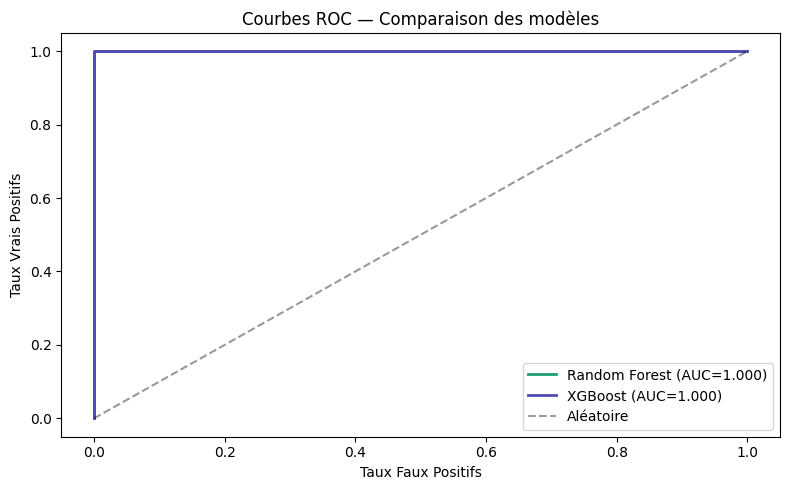

In [10]:
for nom, y_pred, y_proba in [
    ('Random Forest', y_pred_rf,  y_proba_rf),
    ('XGBoost',       y_pred_xgb, y_proba_xgb)
]:
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    print(f"\n{'='*40}")
    print(f"  {nom}")
    print(f"  Accuracy : {acc:.3f}")
    print(f"  AUC-ROC  : {auc:.3f}")
    print(f"{'='*40}")
    print(classification_report(y_test, y_pred,
          target_names=['Actif','Churné']))

# Courbes ROC
plt.figure(figsize=(8, 5))
for nom, y_proba, color in [
    ('Random Forest', y_proba_rf,  '#1D9E75'),
    ('XGBoost',       y_proba_xgb, '#534AB7')
]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, color=color,
             label=f'{nom} (AUC={auc:.3f})', linewidth=2)

plt.plot([0,1],[0,1],'k--', alpha=0.4, label='Aléatoire')
plt.xlabel('Taux Faux Positifs')
plt.ylabel('Taux Vrais Positifs')
plt.title('Courbes ROC — Comparaison des modèles')
plt.legend()
plt.tight_layout()
plt.show()

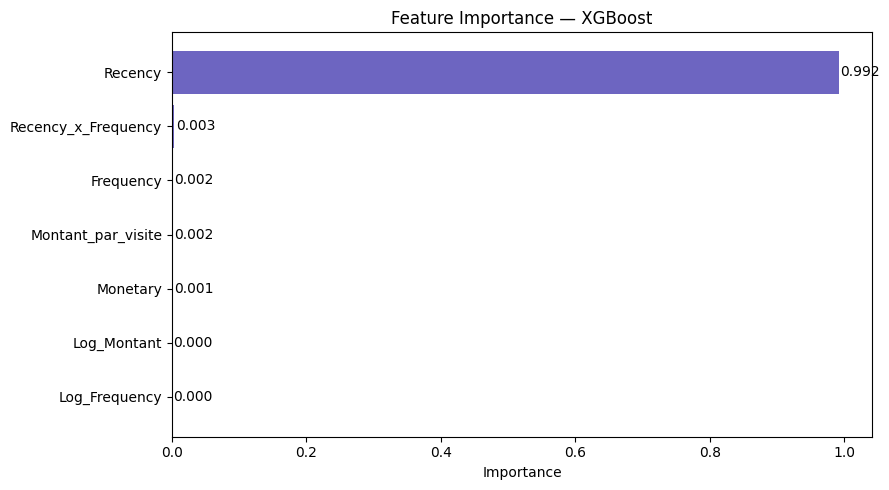


📊 Variable la plus importante : Recency


In [11]:
feat_imp = pd.Series(xgb.feature_importances_,
                     index=FEATURES).sort_values(ascending=True)

plt.figure(figsize=(9, 5))
bars = plt.barh(feat_imp.index, feat_imp.values,
                color='#534AB7', alpha=0.85)
plt.xlabel('Importance')
plt.title('Feature Importance — XGBoost')

for bar, val in zip(bars, feat_imp.values):
    plt.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print(f"\n📊 Variable la plus importante : {feat_imp.idxmax()}")

In [12]:
auc_rf  = roc_auc_score(y_test, y_proba_rf)
auc_xgb = roc_auc_score(y_test, y_proba_xgb)

meilleur = xgb if auc_xgb >= auc_rf else rf
meilleur_nom = 'XGBoost' if auc_xgb >= auc_rf else 'Random Forest'
print(f"✅ Meilleur modèle : {meilleur_nom}")

X_all_sc = scaler.transform(X)
rfm['Proba_Churn'] = meilleur.predict_proba(X_all_sc)[:, 1]
rfm['Churn_Predit'] = meilleur.predict(X_all_sc)
rfm['Risque'] = pd.cut(rfm['Proba_Churn'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Faible', 'Moyen', 'Élevé'])

output = r'E:\projet stage PFE\PFE-Marjane-Optimization\churn_predictions.csv'
rfm.to_csv(output, index=False)

print(f"📁 Fichier exporté : churn_predictions.csv")
print(f"\n📊 Distribution des risques :")
print(rfm['Risque'].value_counts())
print(f"\n🔴 Clients à risque élevé : {(rfm['Risque']=='Élevé').sum()}")

✅ Meilleur modèle : XGBoost
📁 Fichier exporté : churn_predictions.csv

📊 Distribution des risques :
Risque
Faible    3450
Élevé     2406
Moyen        4
Name: count, dtype: int64

🔴 Clients à risque élevé : 2406


In [3]:
import pandas as pd
import numpy as np

# Charger le fichier
churn = pd.read_csv(r'E:\projet stage PFE\PFE-Marjane-Optimization\churn_predictions.csv')

# ── Fichier 1 : powerbi_clients.csv ──
powerbi_clients = churn[[
    'Recency', 'Frequency', 'Monetary',
    'City', 'Segment_Name', 'Cluster',
    'RFM_Score', 'Churn', 'Proba_Churn', 'Risque'
]].copy()

powerbi_clients.columns = [
    'Recence', 'Frequence', 'Montant',
    'Ville', 'Segment', 'Cluster',
    'RFM_Score', 'Churn', 'Proba_Churn', 'Risque'
]

path1 = r'E:\projet stage PFE\PFE-Marjane-Optimization\powerbi_clients.csv'
powerbi_clients.to_csv(path1, index=False)
print(f"✅ powerbi_clients.csv exporté : {len(powerbi_clients)} clients")
print(f"Segments : {powerbi_clients['Segment'].value_counts().to_dict()}")

# ── Fichier 2 : powerbi_kpis.csv ──
kpis = pd.DataFrame({
    'Indicateur': [
        'Total Clients',
        'CA Total (MAD)',
        'Panier Moyen (MAD)',
        'Taux Churn (%)',
        'Clients Risque Élevé',
        'Clients Risque Moyen',
        'Clients Risque Faible'
    ],
    'Valeur': [
        len(powerbi_clients),
        round(powerbi_clients['Montant'].sum(), 2),
        round(powerbi_clients['Montant'].mean(), 2),
        round(powerbi_clients['Churn'].mean() * 100, 1),
        len(powerbi_clients[powerbi_clients['Risque']=='Élevé']),
        len(powerbi_clients[powerbi_clients['Risque']=='Moyen']),
        len(powerbi_clients[powerbi_clients['Risque']=='Faible'])
    ]
})

path2 = r'E:\projet stage PFE\PFE-Marjane-Optimization\powerbi_kpis.csv'
kpis.to_csv(path2, index=False)
print(f"\n✅ powerbi_kpis.csv exporté !")
print(f"\n📊 KPIs :")
print(kpis.to_string(index=False))

✅ powerbi_clients.csv exporté : 5860 clients
Segments : {'Clients à Risque / Perdus': 3821, 'Clients Réguliers': 1998, 'VIP / Champions': 37, 'Gros Acheteurs Occasionnels': 4}

✅ powerbi_kpis.csv exporté !

📊 KPIs :
           Indicateur      Valeur
        Total Clients     5860.00
       CA Total (MAD) 17324932.09
   Panier Moyen (MAD)     2956.47
       Taux Churn (%)       41.10
 Clients Risque Élevé     2406.00
 Clients Risque Moyen        4.00
Clients Risque Faible     3450.00


In [2]:
import pandas as pd

# Charger les deux fichiers
rfm = pd.read_csv(r'E:\projet stage PFE\PFE-Marjane-Optimization\rfm_export.csv')
churn = pd.read_csv(r'E:\projet stage PFE\PFE-Marjane-Optimization\churn_predictions.csv')

print("Colonnes rfm_export :")
print(rfm.columns.tolist())
print(f"\nNombre lignes rfm   : {len(rfm)}")
print(f"Nombre lignes churn : {len(churn)}")

Colonnes rfm_export :
['Recency', 'Frequency', 'Monetary', 'City', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score', 'Cluster', 'Segment_Name']

Nombre lignes rfm   : 5860
Nombre lignes churn : 5860
